In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from src.loader.reader import Dataset_BigEarthNet, Reader

## Evaluate the Imbalanced classes at the parquet df

In [4]:
df_parquet = pd.read_parquet('/root/storage_ds/metadata.parquet')

In [4]:
## For all samples
## For all samples

mlb = MultiLabelBinarizer()
labels_matrix = mlb.fit_transform(df_parquet['labels'])

# Convert to DataFrame for easy use
labels_df = pd.DataFrame(labels_matrix, columns=mlb.classes_)
labels_df.head()

NameError: name 'df_parquet' is not defined

In [20]:
def analyse_inbalance(df):
    mlb = MultiLabelBinarizer()
    labels_matrix = mlb.fit_transform(df['labels'])

    # Convert to DataFrame for easy use
    labels_df = pd.DataFrame(labels_matrix, columns=mlb.classes_)
    labels_df.head()

    df_sum = pd.DataFrame()
    df_sum['labels'] = labels_df.columns.values
    df_sum['sum'] = labels_df.sum(0).values
    df_sum['percent'] = (labels_df.sum(0).values/labels_df.sum(0).values.sum())*100
    df_sum['num_negatives'] = (labels_df.T.sum(1).sum()- labels_df.T.sum(1)).values
    df_sum['neg/pos'] = df_sum['num_negatives']/df_sum['sum']
    return df_sum

def plot_imbalanced(df_sum, column_to_plot):
    df_sum.set_index('labels')[[column_to_plot]].plot(kind='bar')

def plot_compare(df_test, df_total, column_to_plot):
    import matplotlib.pyplot as plt

    fig, axs = plt.subplots(1, 2, figsize=(16, 6))

    df_test.set_index('labels')[[column_to_plot]].plot(kind='bar', ax=axs[0], title='Sampled')
    df_total.set_index('labels')[[column_to_plot]].plot(kind='bar', ax=axs[1], title='Full')

    axs[0].set_ylabel('Percent')
    axs[1].set_ylabel('Percent')
    axs[0].set_xlabel('Labels')
    axs[1].set_xlabel('Labels')

    plt.tight_layout()
    plt.show()

In [6]:


mlb = MultiLabelBinarizer()
labels_matrix = mlb.fit_transform(df_parquet['labels'])

# Convert to DataFrame for easy use
labels_df = pd.DataFrame(labels_matrix, columns=mlb.classes_)
labels_df.head()

df_sum = pd.DataFrame()
df_sum['labels'] = labels_df.columns.values
df_sum['sum'] = labels_df.sum(0).values
df_sum['percent'] = (labels_df.sum(0).values/labels_df.sum(0).values.sum())*100
df_sum['num_negatives'] = (labels_df.T.sum(1).sum()- labels_df.T.sum(1)).values
df_sum['neg/pos'] = df_sum['num_negatives']/df_sum['sum']
weights = np.clip(df_sum['neg/pos'].values,1,100)

NameError: name 'df_parquet' is not defined

In [8]:
labels_df

,Agro-forestry areas,Arable land,"Beaches, dunes, sands",Broad-leaved forest,Coastal wetlands,Complex cultivation patterns,Coniferous forest,Industrial or commercial units,Inland waters,Inland wetlands,"Land principally occupied by agriculture, with significant areas of natural vegetation",Marine waters,Mixed forest,"Moors, heathland and sclerophyllous vegetation",Natural grassland and sparsely vegetated areas,Pastures,Permanent crops,"Transitional woodland, shrub",Urban fabric
0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0
1,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
2,0,1,0,1,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0
3,0,0,0,1,0,1,1,0,1,0,0,0,1,0,0,0,0,0,0
4,0,0,0,1,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
480033,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0
480034,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0
480035,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
480036,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0


In [9]:
df_sum

,labels,sum,percent,num_negatives,neg/pos
0,Agro-forestry areas,33181,2.343528,1382676,41.670715
1,Arable land,188025,13.279943,1227832,6.530153
2,"Beaches, dunes, sands",1316,0.092947,1414541,1074.879179
3,Broad-leaved forest,135928,9.600405,1279929,9.416228
4,Coastal wetlands,1397,0.098668,1414460,1012.498210
5,Complex cultivation patterns,99598,7.034467,1316259,13.215717
6,Coniferous forest,154941,10.943266,1260916,8.138040
7,Industrial or commercial units,11142,0.786944,1404715,126.073865
8,Inland waters,63212,4.464575,1352645,21.398548
9,Inland wetlands,20919,1.477480,1394938,66.682824


In [249]:
df_sum.labels.values

array(['Agro-forestry areas', 'Arable land', 'Beaches, dunes, sands',
       'Broad-leaved forest', 'Coastal wetlands',
       'Complex cultivation patterns', 'Coniferous forest',
       'Industrial or commercial units', 'Inland waters',
       'Inland wetlands',
       'Land principally occupied by agriculture, with significant areas of natural vegetation',
       'Marine waters', 'Mixed forest',
       'Moors, heathland and sclerophyllous vegetation',
       'Natural grassland and sparsely vegetated areas', 'Pastures',
       'Permanent crops', 'Transitional woodland, shrub', 'Urban fabric'],
      dtype=object)

<Axes: xlabel='labels'>

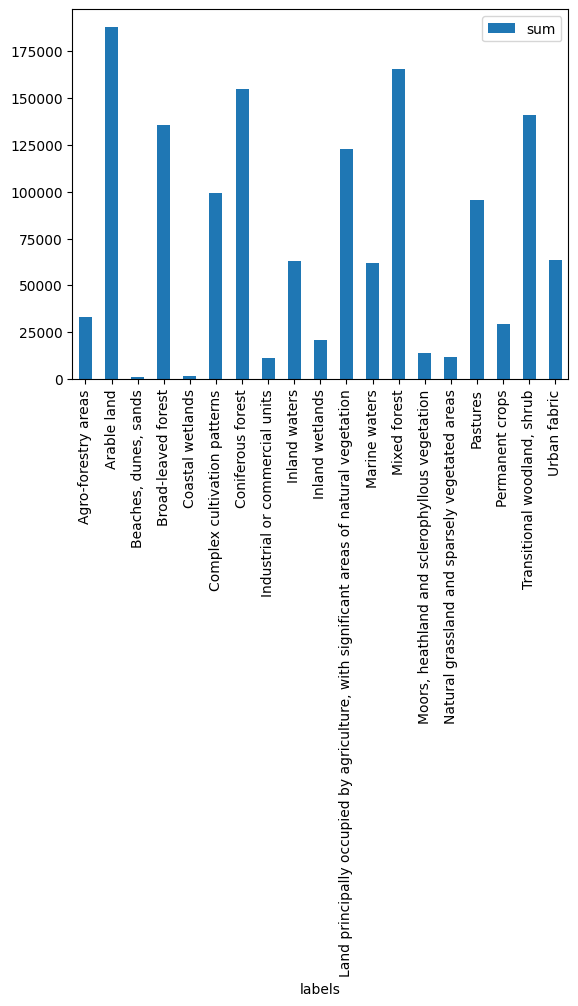

In [10]:
df_sum.set_index('labels')[['sum']].plot(kind='bar')

## Training

In [86]:
## For training

mlb = MultiLabelBinarizer()
labels_matrix = mlb.fit_transform(df_parquet['labels'].loc[df_parquet['split']=='train'])

# Convert to DataFrame for easy use
labels_df = pd.DataFrame(labels_matrix, columns=mlb.classes_)
labels_df.head()

train_df_sum = pd.DataFrame()
train_df_sum['labels'] = labels_df.columns.values
train_df_sum['sum'] = labels_df.sum(0).values
train_df_sum['percent'] = (labels_df.sum(0).values/labels_df.sum(0).values.sum())*100
train_df_sum['num_negatives'] = (labels_df.T.sum(1).sum()- labels_df.T.sum(1)).values
train_df_sum['neg/pos'] = train_df_sum['num_negatives']/train_df_sum['sum']
weights = np.clip(train_df_sum['neg/pos'].values,1,100)

In [60]:
df_sum

,labels,sum,percent,num_negatives,neg/pos
0,Agro-forestry areas,15082,2.190232,673521,44.657274
1,Arable land,88236,12.813769,600367,6.804105
2,"Beaches, dunes, sands",738,0.107174,687865,932.066396
3,Broad-leaved forest,64164,9.317996,624439,9.731921
4,Coastal wetlands,670,0.097298,687933,1026.765672
5,Complex cultivation patterns,51034,7.411237,637569,12.493024
6,Coniferous forest,76344,11.086795,612259,8.019740
7,Industrial or commercial units,6398,0.929128,682205,106.627852
8,Inland waters,30466,4.424320,658137,21.602344
9,Inland wetlands,11344,1.647393,677259,59.701957


<Axes: xlabel='labels'>

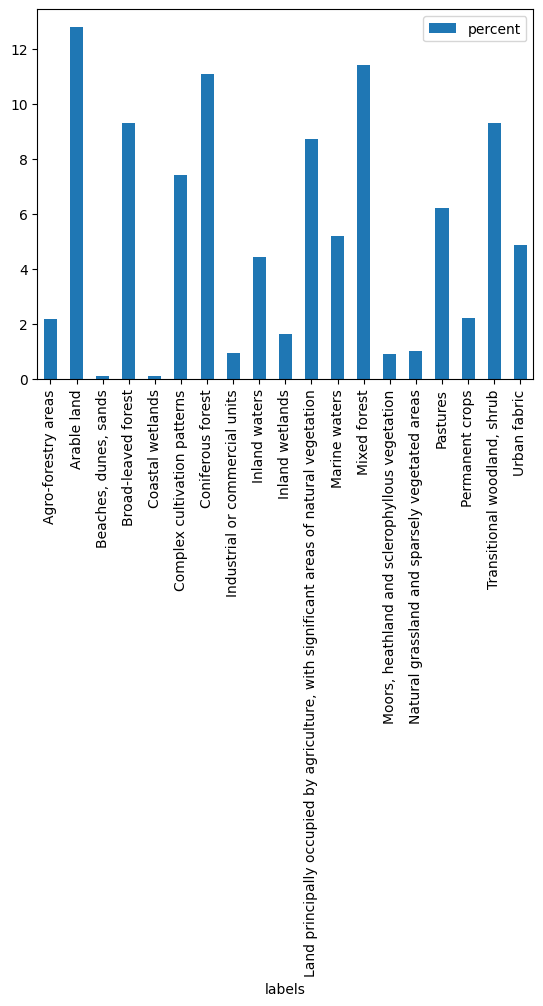

In [ ]:
train_df_sum.set_index('labels')[['percent']].plot(kind='bar')

## Validation

In [57]:

mlb = MultiLabelBinarizer()
labels_matrix = mlb.fit_transform(df_parquet['labels'].loc[df_parquet['split']=='validation'])

# Convert to DataFrame for easy use
labels_df = pd.DataFrame(labels_matrix, columns=mlb.classes_)
labels_df.head()

df_sum = pd.DataFrame()
df_sum['labels'] = labels_df.columns.values
df_sum['sum'] = labels_df.sum(0).values
df_sum['percent'] = (labels_df.sum(0).values/labels_df.sum(0).values.sum())*100
df_sum['num_negatives'] = (labels_df.T.sum(1).sum()- labels_df.T.sum(1)).values
df_sum['neg/pos'] = df_sum['num_negatives']/df_sum['sum']
weights = np.clip(df_sum['neg/pos'].values,1,100)

In [58]:
df_sum

,labels,sum,percent,num_negatives,neg/pos
0,Agro-forestry areas,8157,2.214308,360220,44.160843
1,Arable land,49737,13.501657,318640,6.406498
2,"Beaches, dunes, sands",426,0.115642,367951,863.734742
3,Broad-leaved forest,35387,9.606191,332990,9.409953
4,Coastal wetlands,610,0.165591,367767,602.896721
5,Complex cultivation patterns,26486,7.189917,341891,12.908367
6,Coniferous forest,39554,10.737370,328823,8.313268
7,Industrial or commercial units,2726,0.740003,365651,134.134629
8,Inland waters,15900,4.316230,352477,22.168365
9,Inland wetlands,5056,1.372507,363321,71.859375


<Axes: xlabel='labels'>

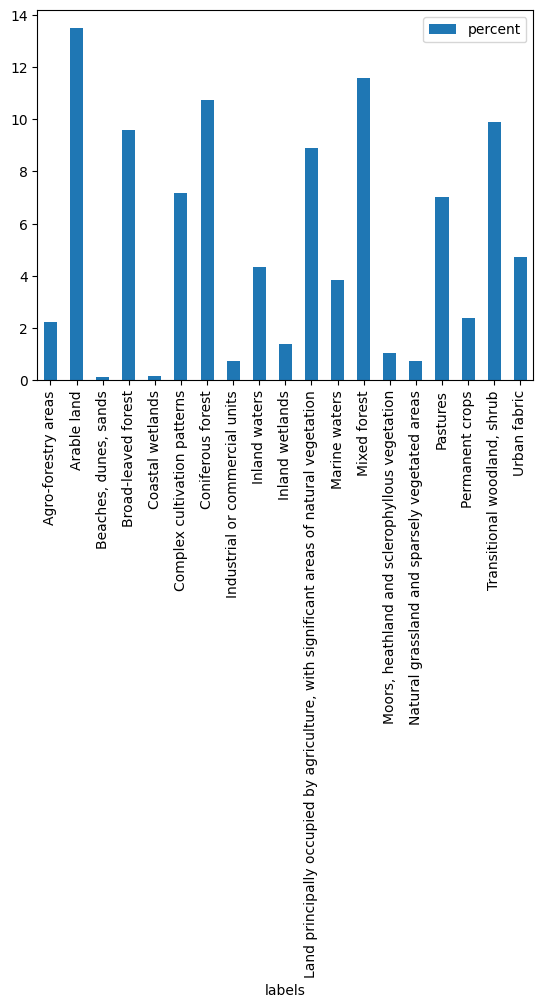

In [48]:
df_sum.set_index('labels')[['percent']].plot(kind='bar')

## Train with partial dataset 

20% of the train dataset

In [62]:
label_to_idx = {
    'Arable land': 0,
    'Broad-leaved forest': 1,
    'Mixed forest': 2,
    'Pastures': 3,
    'Inland waters': 4,
    'Coniferous forest': 5,
    'Complex cultivation patterns': 6,
    'Land principally occupied by agriculture, with significant areas of natural vegetation': 7,
    'Urban fabric': 8,
    'Industrial or commercial units': 9,
    'Inland wetlands': 10,
    'Transitional woodland, shrub': 11,
    'Natural grassland and sparsely vegetated areas': 12,
    'Moors, heathland and sclerophyllous vegetation': 13,
    'Marine waters': 14,
    'Coastal wetlands': 15,
    'Permanent crops': 16,
    'Beaches, dunes, sands': 17,
    'Agro-forestry areas': 18
}

In [64]:

reader = Reader("~/storage_ds/BigEarthNet-S2", "/root/storage_ds/metadata.parquet")

datasetmod = Dataset_BigEarthNet(
    reader= reader,
    strip_bands = ["B02", "B03", "B04"],
    img_size= 120,
    upsample_mode='nearest',
    normalize =True,
    split_train_test= 'train',
    dict_one_hot=label_to_idx,
    small_fraction=0.25
)

2025-08-14 11:36:37.910 | INFO     | src.loader.reader:__init__:208 - Initializing the Reader, structuring the paths and files.
2025-08-14 11:36:38.400 | INFO     | src.loader.reader:parent_folders:260 - Found 115 folders in /root/storage_ds/BigEarthNet-S2
2025-08-14 11:36:44.330 | INFO     | src.loader.reader:_create_lookup_structures:244 - Created lookup structures for 480038 patches
2025-08-14 11:36:44.331 | INFO     | src.loader.reader:__init__:228 - None
2025-08-14 11:36:44.443 | INFO     | src.loader.reader:__init__:451 - train split, with length of 237871
2025-08-14 11:36:44.444 | WARNING  | src.loader.reader:__init__:459 - Small sample selected. Dataset is reduced!
2025-08-14 11:36:44.444 | INFO     | src.loader.reader:__init__:460 - train split, with length of 59467
2025-08-14 11:36:44.444 | INFO     | src.loader.reader:__init__:469 - Bands orded by: ['B02', 'B03', 'B04']


Number of parent folders: 115
Number of total patches found it: 549488


In [68]:
len(datasetmod.patch_ids_array)

59467

In [75]:
short_train = df_parquet.loc[df_parquet["patch_id"].isin(datasetmod.patch_ids_array)]

In [81]:
mlb = MultiLabelBinarizer()
labels_matrix = mlb.fit_transform(short_train['labels'])

# Convert to DataFrame for easy use
labels_df = pd.DataFrame(labels_matrix, columns=mlb.classes_)
labels_df.head()

smal_df_sum = pd.DataFrame()
smal_df_sum['labels'] = labels_df.columns.values
smal_df_sum['sum'] = labels_df.sum(0).values
smal_df_sum['percent'] = (labels_df.sum(0).values/labels_df.sum(0).values.sum())*100
smal_df_sum['num_negatives'] = (labels_df.T.sum(1).sum()- labels_df.T.sum(1)).values
smal_df_sum['neg/pos'] = smal_df_sum['num_negatives']/smal_df_sum['sum']
weights = np.clip(smal_df_sum['neg/pos'].values,1,100)

In [82]:
smal_df_sum

,labels,sum,percent,num_negatives,neg/pos
0,Agro-forestry areas,7966,4.892670,154849,19.438740
1,Arable land,22470,13.800940,140345,6.245883
2,"Beaches, dunes, sands",306,0.187943,162509,531.075163
3,Broad-leaved forest,11926,7.324878,150889,12.652105
4,Coastal wetlands,309,0.189786,162506,525.909385
5,Complex cultivation patterns,8588,5.274698,154227,17.958430
6,Coniferous forest,17306,10.629242,145509,8.408009
7,Industrial or commercial units,1740,1.068698,161075,92.571839
8,Inland waters,8079,4.962074,154736,19.152865
9,Inland wetlands,2422,1.487578,160393,66.223369


/tmp/ipykernel_3748159/2802410548.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


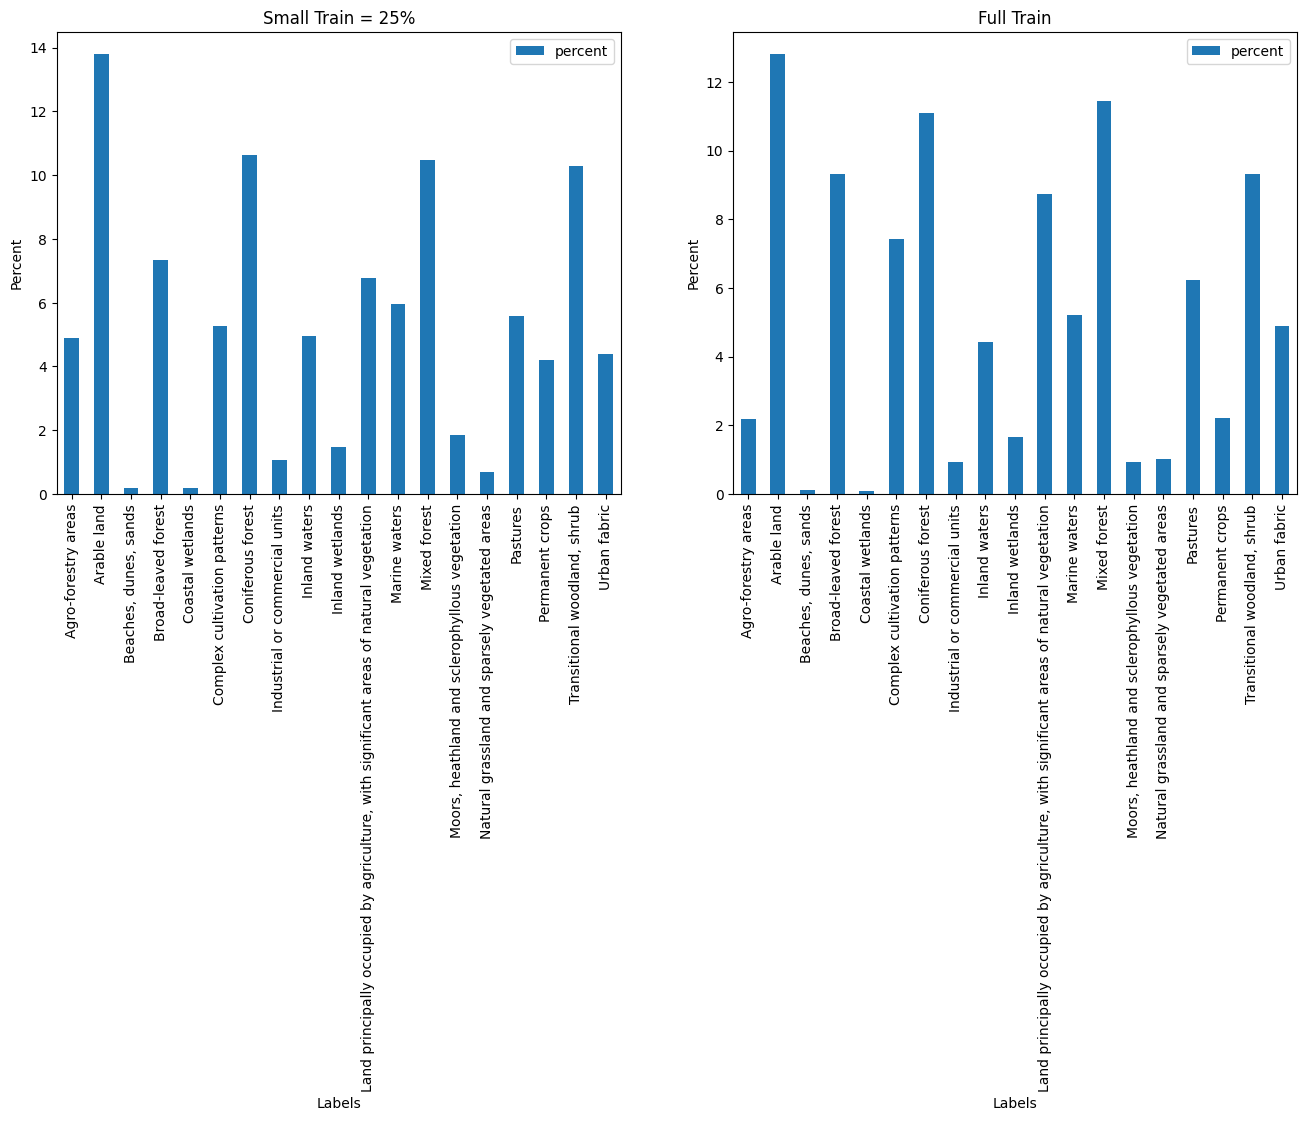

In [87]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

smal_df_sum.set_index('labels')[['percent']].plot(kind='bar', ax=axs[0], title='Small Train = 25%')
train_df_sum.set_index('labels')[['percent']].plot(kind='bar', ax=axs[1], title='Full Train')

axs[0].set_ylabel('Percent')
axs[1].set_ylabel('Percent')
axs[0].set_xlabel('Labels')
axs[1].set_xlabel('Labels')

plt.tight_layout()
plt.show()

/tmp/ipykernel_3748159/1795829468.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


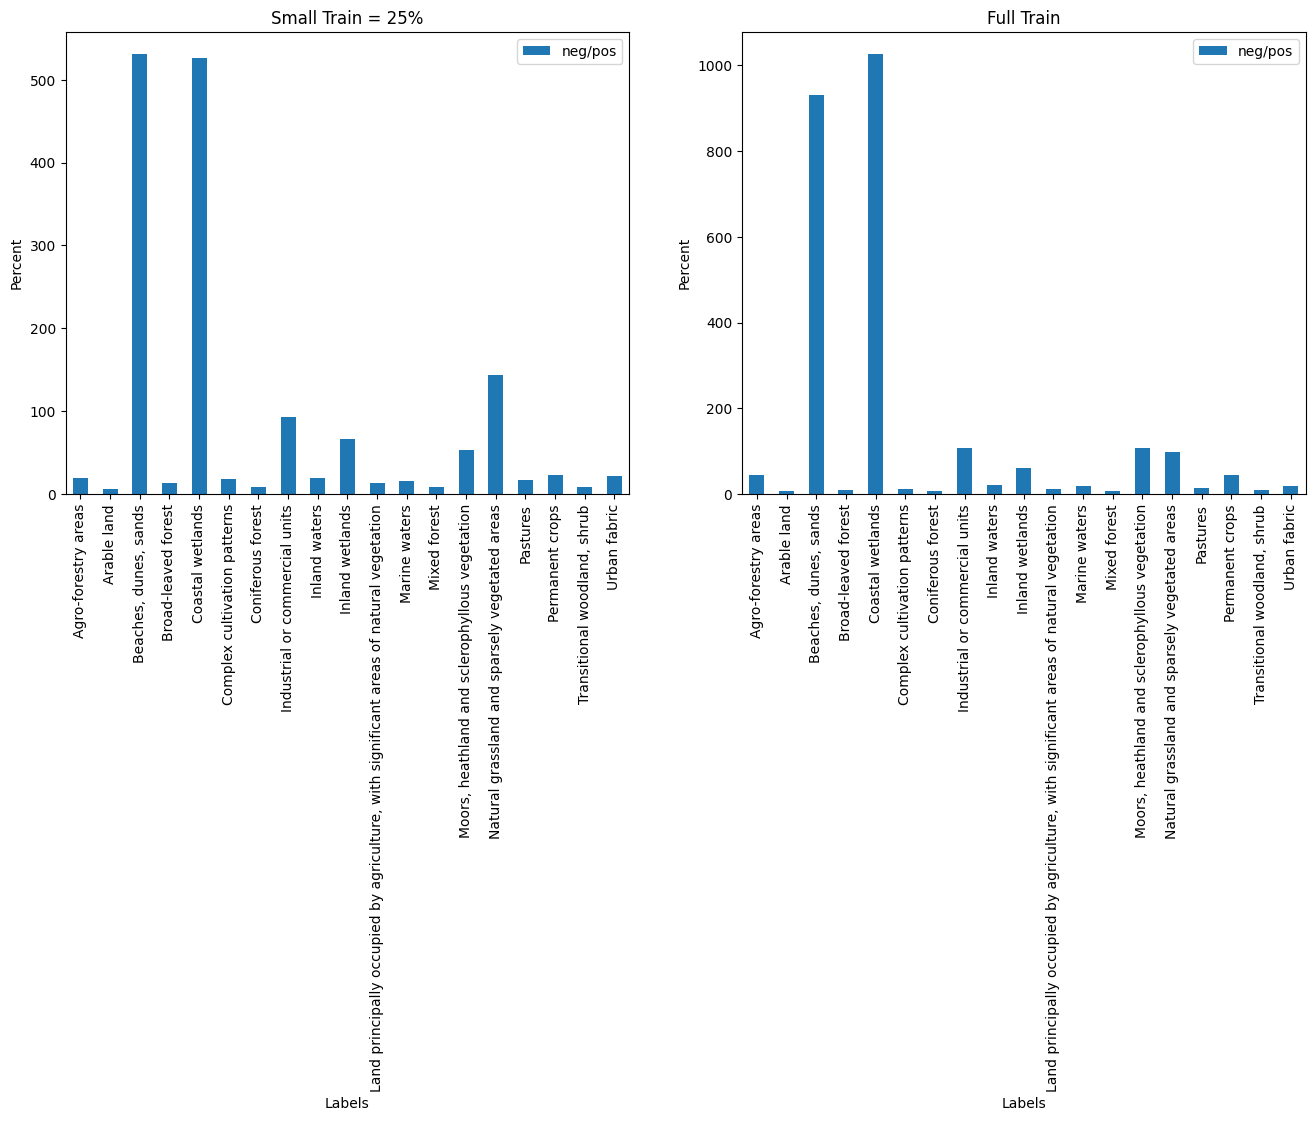

In [88]:
## Comparing Weights

import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

smal_df_sum.set_index('labels')[['neg/pos']].plot(kind='bar', ax=axs[0], title='Small Train = 25%')
train_df_sum.set_index('labels')[['neg/pos']].plot(kind='bar', ax=axs[1], title='Full Train')

axs[0].set_ylabel('Percent')
axs[1].set_ylabel('Percent')
axs[0].set_xlabel('Labels')
axs[1].set_xlabel('Labels')

plt.tight_layout()
plt.show()

/tmp/ipykernel_3748159/3778179578.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


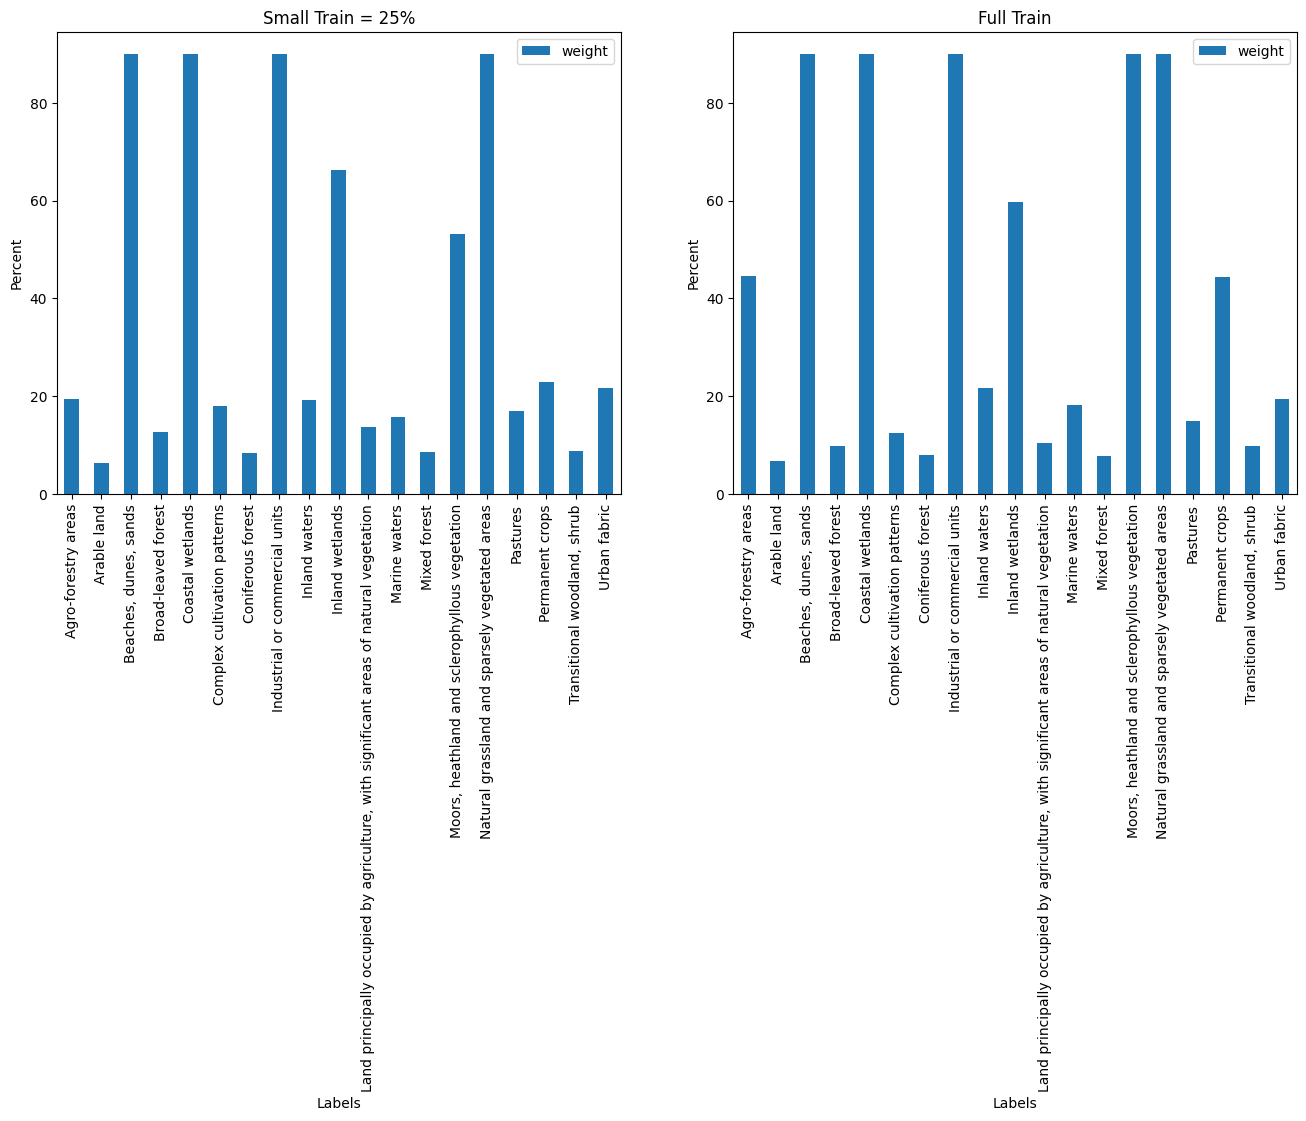

In [91]:
import matplotlib.pyplot as plt

smal_df_sum['weight'] = np.clip(smal_df_sum['neg/pos'].values,1,90)
train_df_sum['weight'] = np.clip(train_df_sum['neg/pos'].values,1,90)

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

smal_df_sum.set_index('labels')[['weight']].plot(kind='bar', ax=axs[0], title='Small Train = 25%')
train_df_sum.set_index('labels')[['weight']].plot(kind='bar', ax=axs[1], title='Full Train')

axs[0].set_ylabel('Percent')
axs[1].set_ylabel('Percent')
axs[0].set_xlabel('Labels')
axs[1].set_xlabel('Labels')

plt.tight_layout()
plt.show()

In [92]:
df_parquet

,patch_id,labels,split,country,s1_name,s2v1_name,contains_seasonal_snow,contains_cloud_or_shadow
0,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,"[Arable land, Broad-leaved forest, Mixed fores...",test,Austria,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_26_57,S2A_MSIL2A_20170613T101031_26_57,False,False
1,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,"[Arable land, Broad-leaved forest, Inland wate...",test,Austria,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_27_55,S2A_MSIL2A_20170613T101031_27_55,False,False
2,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,"[Arable land, Broad-leaved forest, Coniferous ...",test,Austria,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_27_56,S2A_MSIL2A_20170613T101031_27_56,False,False
3,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,"[Broad-leaved forest, Complex cultivation patt...",test,Austria,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_27_57,S2A_MSIL2A_20170613T101031_27_57,False,False
4,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,"[Broad-leaved forest, Complex cultivation patt...",test,Austria,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_27_58,S2A_MSIL2A_20170613T101031_27_58,False,False
...,...,...,...,...,...,...,...,...
480033,S2B_MSIL2A_20180525T094029_N9999_R036_T35VNL_9...,"[Coniferous forest, Mixed forest, Transitional...",train,Finland,S1A_IW_GRDH_1SDV_20180525T153259_35VNL_90_86,S2B_MSIL2A_20180525T094029_90_86,False,False
480034,S2B_MSIL2A_20180525T094029_N9999_R036_T35VNL_9...,"[Coniferous forest, Mixed forest]",train,Finland,S1A_IW_GRDH_1SDV_20180525T153259_35VNL_90_87,S2B_MSIL2A_20180525T094029_90_87,False,False
480035,S2B_MSIL2A_20180525T094029_N9999_R036_T35VNL_9...,[Coniferous forest],train,Finland,S1A_IW_GRDH_1SDV_20180525T153259_35VNL_90_88,S2B_MSIL2A_20180525T094029_90_88,False,False
480036,S2B_MSIL2A_20180525T094029_N9999_R036_T35VNL_9...,[Coniferous forest],train,Finland,S1B_IW_GRDH_1SDV_20180524T154016_35VNL_90_89,S2B_MSIL2A_20180525T094029_90_89,False,False


## Filtering the Dataset for a better balanced position




In [11]:
concat_df = pd.concat([df_parquet,labels_df],axis=1)

In [13]:
concat_df.columns

Index(['patch_id', 'labels', 'split', 'country', 's1_name', 's2v1_name',
       'contains_seasonal_snow', 'contains_cloud_or_shadow',
       'Agro-forestry areas', 'Arable land', 'Beaches, dunes, sands',
       'Broad-leaved forest', 'Coastal wetlands',
       'Complex cultivation patterns', 'Coniferous forest',
       'Industrial or commercial units', 'Inland waters', 'Inland wetlands',
       'Land principally occupied by agriculture, with significant areas of natural vegetation',
       'Marine waters', 'Mixed forest',
       'Moors, heathland and sclerophyllous vegetation',
       'Natural grassland and sparsely vegetated areas', 'Pastures',
       'Permanent crops', 'Transitional woodland, shrub', 'Urban fabric'],
      dtype='object')

In [24]:
df_verf_ = concat_df[concat_df['Arable land']==1].sample(random_state=42,n=20000)

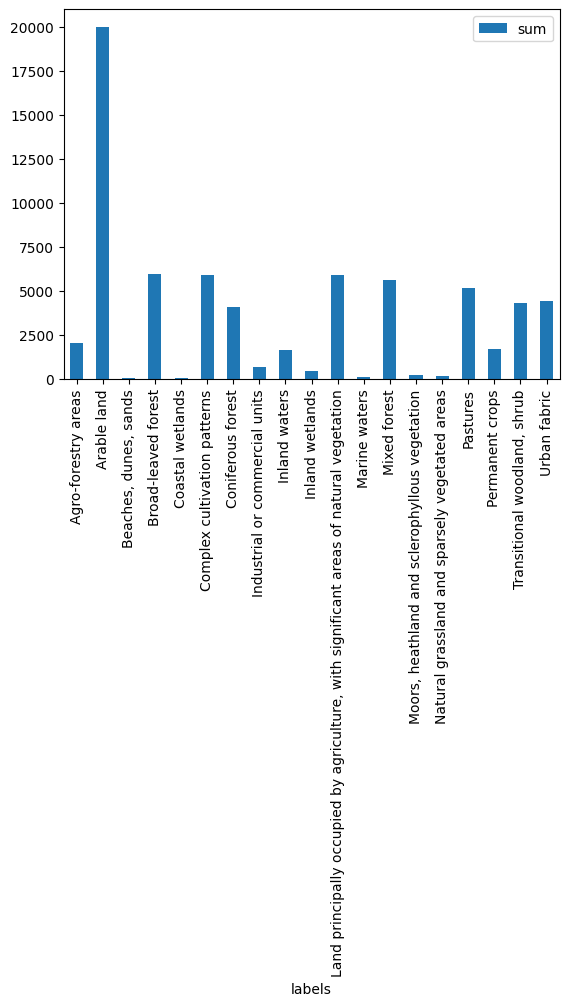

In [25]:
test1 = analyse_inbalance(df_verf_)
plot_imbalanced(test1, 'sum')

/tmp/ipykernel_4025718/473169443.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


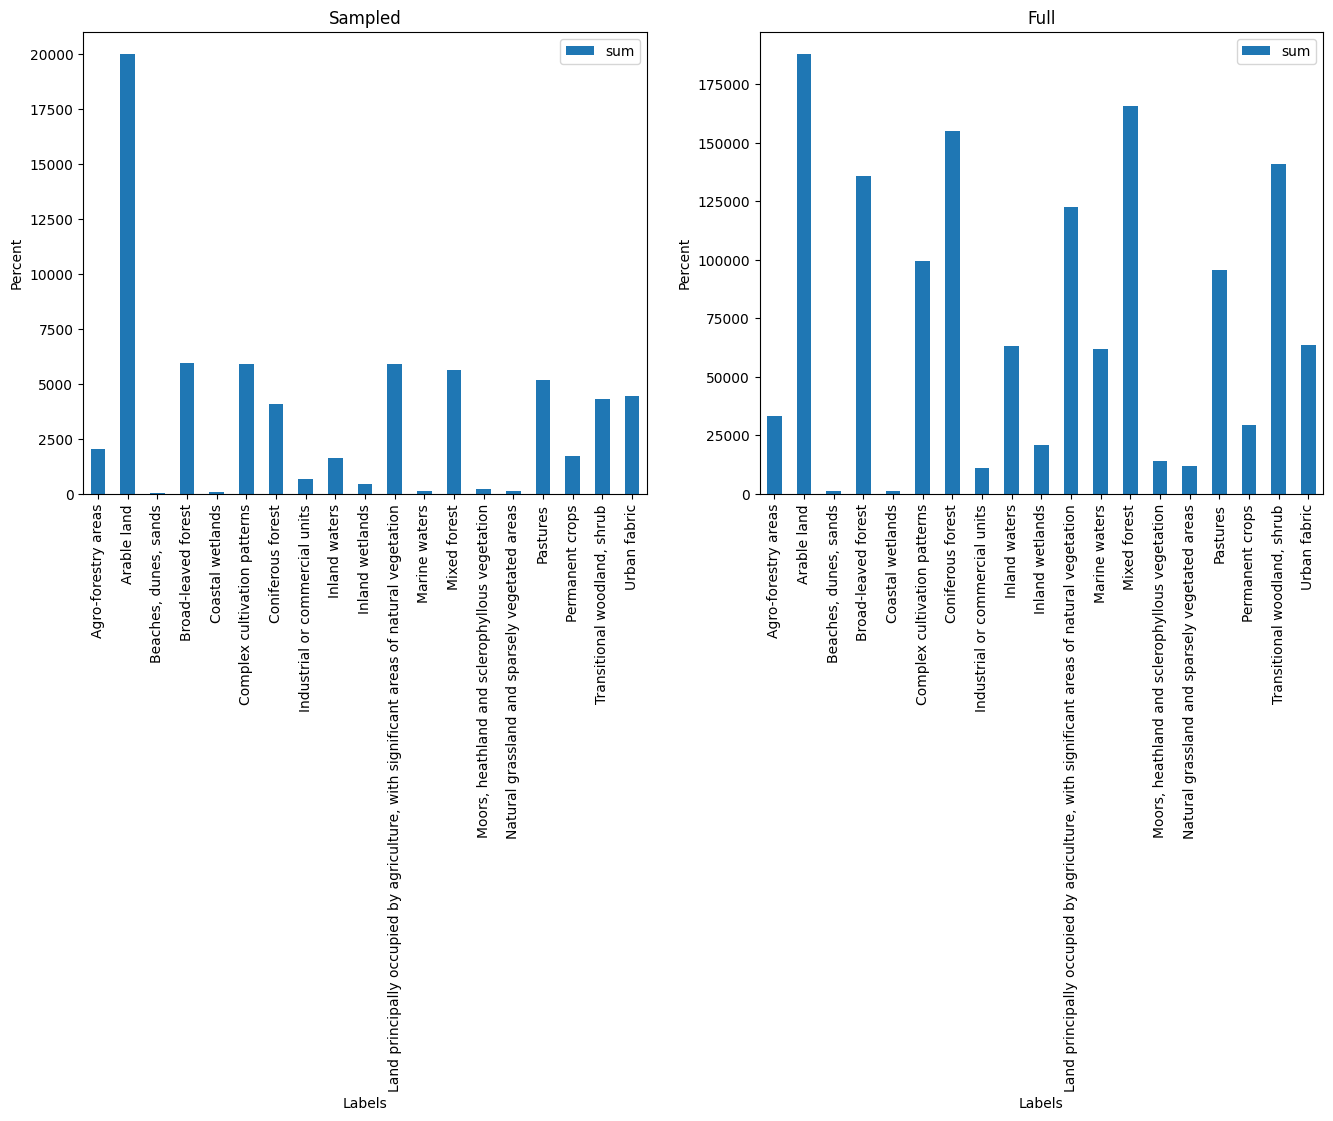

In [31]:
plot_compare(test1, df_sum, 'sum')

/tmp/ipykernel_4025718/473169443.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


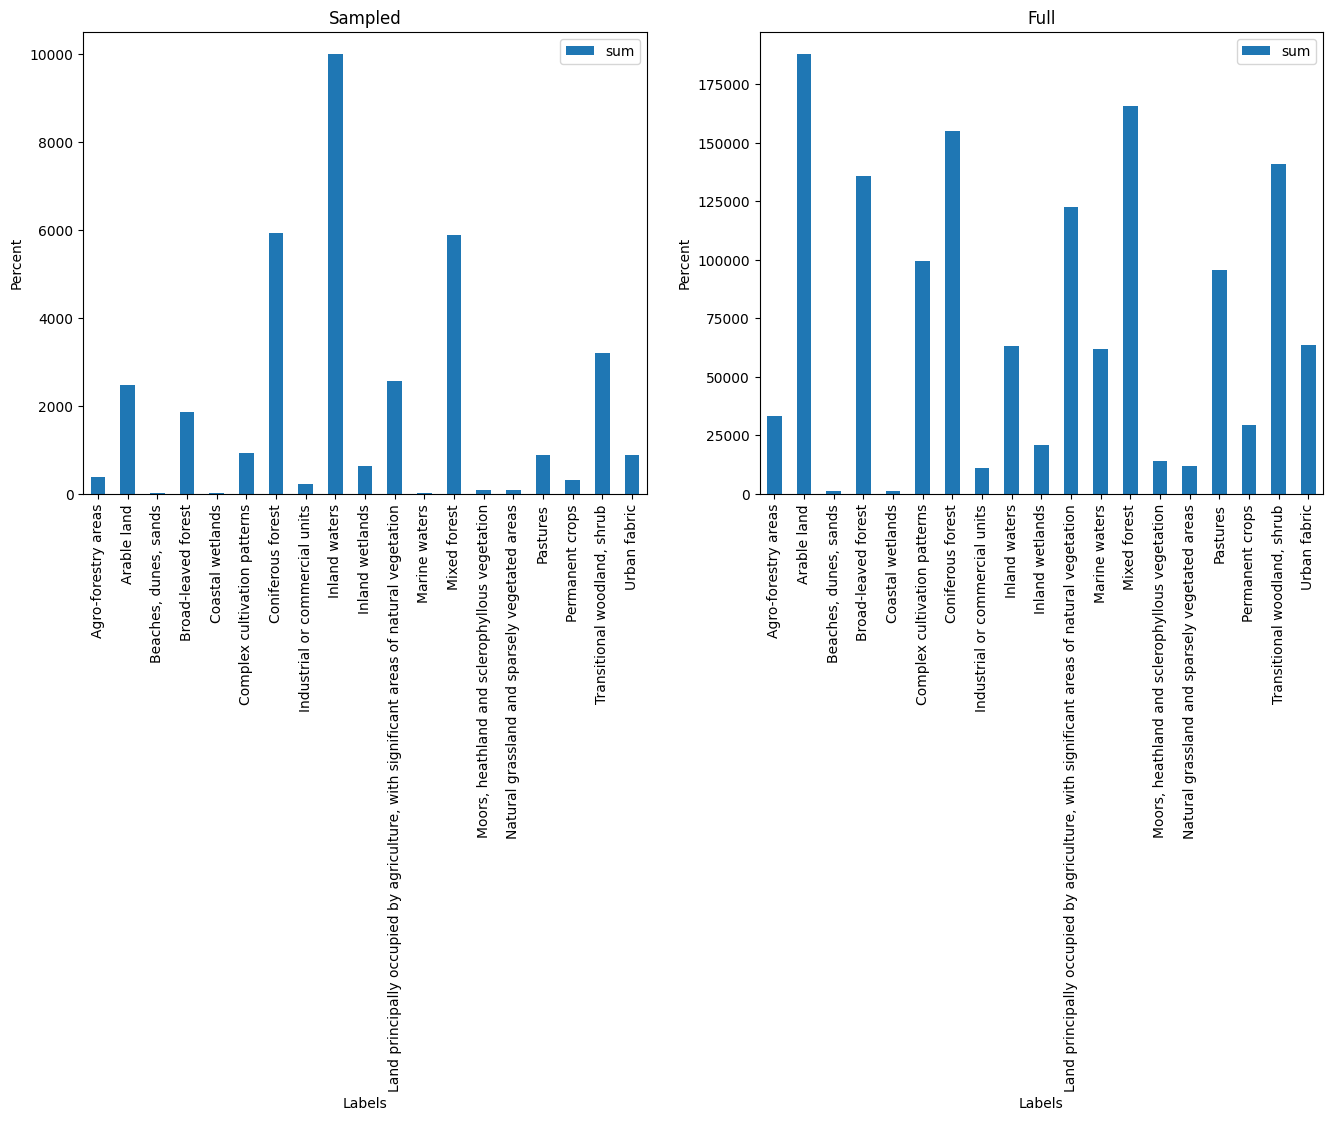

In [33]:
df_test2 = concat_df[concat_df['Inland waters']==1].sample(random_state=42,n=10000)
test2 = analyse_inbalance(df_test2)
plot_compare(test2, df_sum, 'sum')

In [37]:
df_verf_.columns==test2.columns

ValueError: Lengths must match to compare

/tmp/ipykernel_4025718/473169443.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


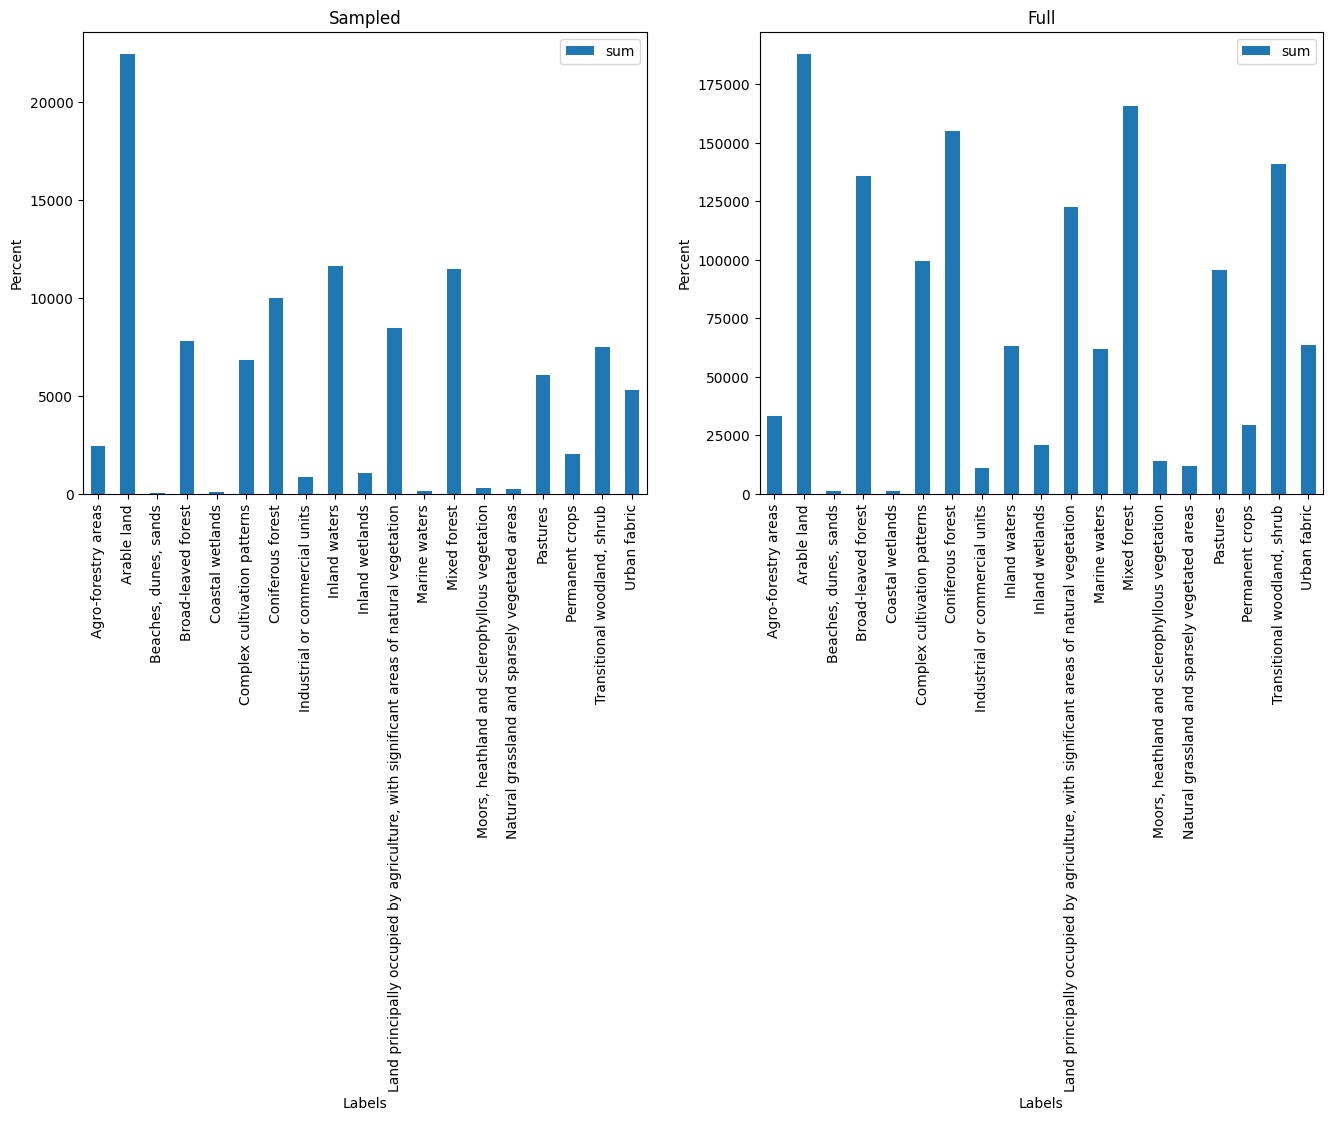

In [45]:
df_try_concat = pd.concat([df_verf_,df_test2],axis=0)
test3 = analyse_inbalance(df_try_concat)
plot_compare(test3, df_sum, 'sum')

In [77]:
def sampling_dataset(max_number_of_samples=10000,threshold_sum_values=10000):
    for i,lab in enumerate(df_sum[df_sum['sum']>threshold_sum_values]['labels'].values):
        if i==0:
        ## Selec true values 
            df_true = concat_df[concat_df[lab]==1].sample(random_state=42,n=max_number_of_samples)
            df_concat = df_true.copy()
            print(f"Size of first concat: {df_concat.shape}")

        else:
            df_true=concat_df[concat_df[lab]==1].sample(random_state=42,n=10000)
            df_concat = pd.concat([df_concat,df_true],axis=0)
            print(f"concat size: {df_concat.shape}")

    ## Get Unique patch_id
    concat_unique_patch = df_concat['patch_id'].unique()
    print(f"Total size: {len(concat_unique_patch)}")
    print(f"Size of unique patch id:{len(concat_unique_patch)}")
        
    ## Return a new dataset sampled by the maximum value attribute to each class
    df_return = df_concat.drop_duplicates(['patch_id'])
    print(f"Shape of new df: {df_return.shape}")
    return df_return

In [76]:
new_df_concat = sampling_dataset()

Size of first concat: (10000, 27)
concat size: (20000, 27)
concat size: (30000, 27)
concat size: (40000, 27)
concat size: (50000, 27)
concat size: (60000, 27)
concat size: (70000, 27)
concat size: (80000, 27)
concat size: (90000, 27)
concat size: (100000, 27)
concat size: (110000, 27)
concat size: (120000, 27)
concat size: (130000, 27)
concat size: (140000, 27)
concat size: (150000, 27)
concat size: (160000, 27)
concat size: (170000, 27)
Total size: 145781
Size of unique patch id:145781


In [78]:
df_test4 = analyse_inbalance(new_df_concat)

/tmp/ipykernel_4025718/473169443.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


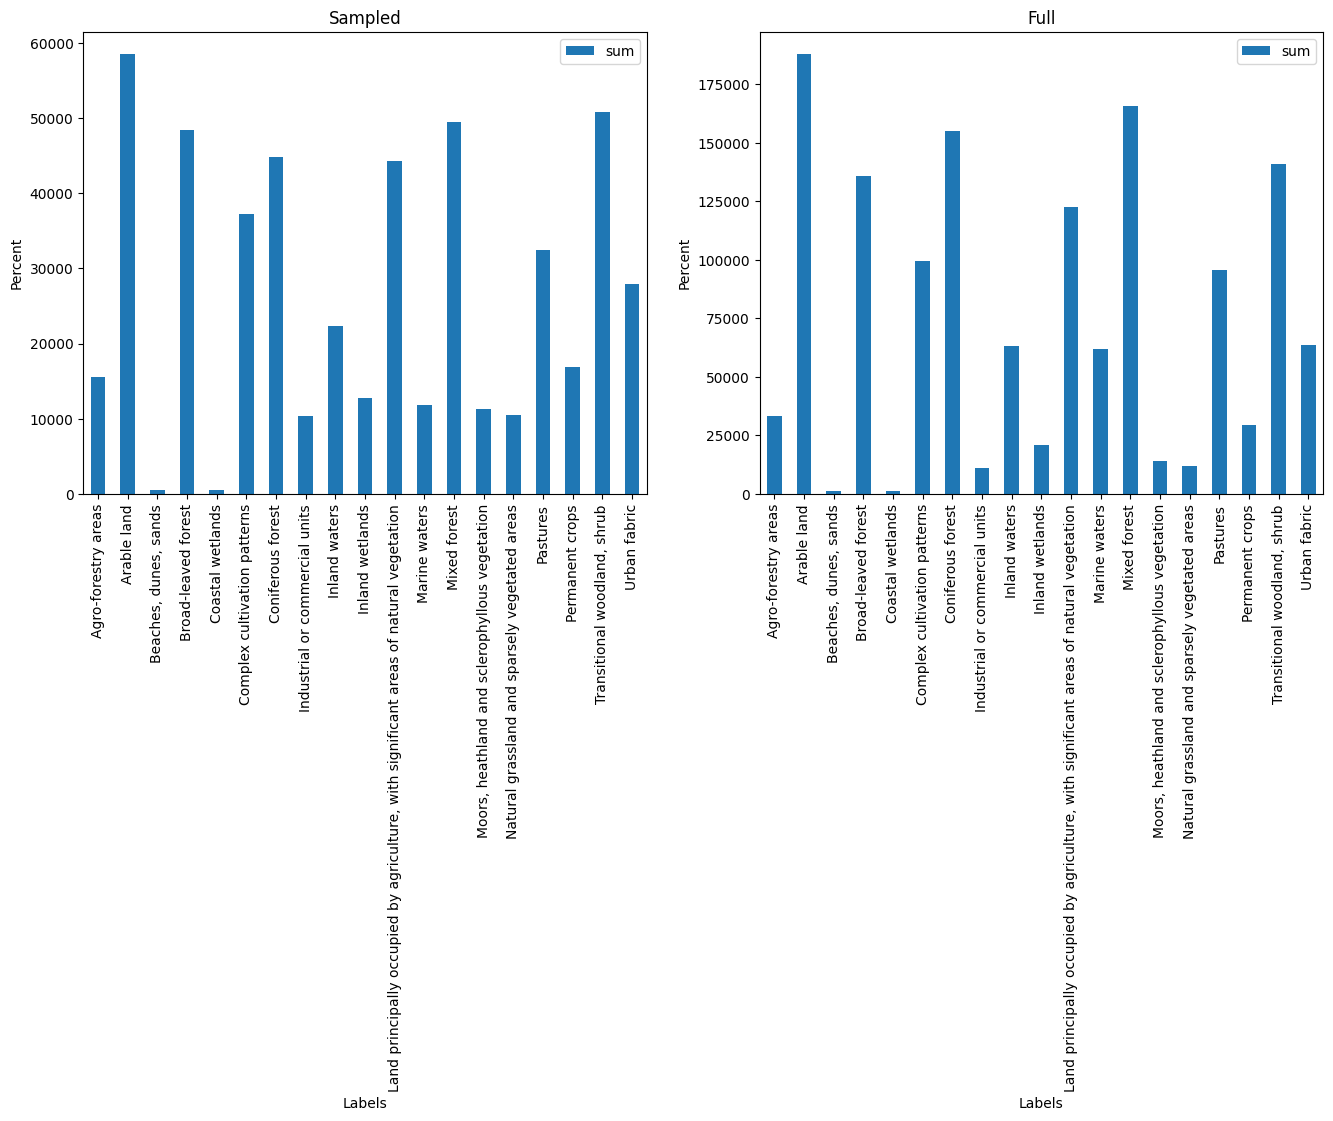

In [79]:
plot_compare(df_test4,df_sum, 'sum')

In [84]:
new_df_concat.columns

Index(['patch_id', 'labels', 'split', 'country', 's1_name', 's2v1_name',
       'contains_seasonal_snow', 'contains_cloud_or_shadow',
       'Agro-forestry areas', 'Arable land', 'Beaches, dunes, sands',
       'Broad-leaved forest', 'Coastal wetlands',
       'Complex cultivation patterns', 'Coniferous forest',
       'Industrial or commercial units', 'Inland waters', 'Inland wetlands',
       'Land principally occupied by agriculture, with significant areas of natural vegetation',
       'Marine waters', 'Mixed forest',
       'Moors, heathland and sclerophyllous vegetation',
       'Natural grassland and sparsely vegetated areas', 'Pastures',
       'Permanent crops', 'Transitional woodland, shrub', 'Urban fabric'],
      dtype='object')

In [120]:
print('---'*30)

------------------------------------------------------------------------------------------


In [144]:
imbalance = np.array([1.16050919e+01, 4.75301415e+00, 5.06430769e+03, 5.70082426e+00,
 1.82813889e+03, 6.83263947e+00, 2.46821373e+01, 1.24188213e+02,
 4.94203675e+01, 2.55221790e+02, 1.02427864e+01, 8.22112500e+02,
 1.45561068e+01, 1.79903846e+02, 1.15546903e+02, 1.47382887e+01,
 2.77048823e+01 ,1.18611328e+01 ,1.75699380e+01])

new_imbalance = imbalance

In [145]:
np.histogram(imbalance)

(array([16,  1,  0,  1,  0,  0,  0,  0,  0,  1]),
 array([4.75301415e+00, 5.10708482e+02, 1.01666395e+03, 1.52261942e+03,
        2.02857488e+03, 2.53453035e+03, 3.04048582e+03, 3.54644129e+03,
        4.05239675e+03, 4.55835222e+03, 5.06430769e+03]))

In [141]:
new_imbalance[imbalance>np.percentile(imbalance, 95)]=20.00
new_imbalance[imbalance>np.percentile(imbalance, 90)]=12.00

In [146]:
import numpy as np

def improve_position_weights(imbalance):
    """
    Improve position weights for BCELogitLoss
    
    Strategy:
    - Values > 98th percentile = 20
    - Values > 90th and <= 98th percentile = 12  
    - Values > 75th and <= 90th percentile = 10
    - Values <= 75th percentile = scaled from 1 to 10
    """
    new_imbalance = imbalance.copy()
    
    # Calculate percentiles
    p98 = np.percentile(imbalance, 98)
    p90 = np.percentile(imbalance, 90)
    p75 = np.percentile(imbalance, 75)
    
    print(f"98th percentile: {p98:.2f}")
    print(f"90th percentile: {p90:.2f}")
    print(f"75th percentile: {p75:.2f}")
    
    # Apply transformations (order matters - start from highest)
    # 1. Values > 98th percentile = 20
    new_imbalance[imbalance > p98] = 20.0
    
    # 2. Values > 90th and <= 98th percentile = 12
    mask_90_98 = (imbalance > p90) & (imbalance <= p98)
    new_imbalance[mask_90_98] = 12.0
    
    # 3. Values > 75th and <= 90th percentile = 10
    mask_75_90 = (imbalance > p75) & (imbalance <= p90)
    new_imbalance[mask_75_90] = 10.0
    
    # 4. Scale remaining values (<=75th percentile) from 1 to 10
    mask_below_75 = imbalance <= p75
    if np.any(mask_below_75):
        values_below_75 = imbalance[mask_below_75]
        min_val = values_below_75.min()
        max_val = values_below_75.max()
        
        # Scale from 1 to 10
        if max_val > min_val:  # Avoid division by zero
            scaled_values = 1 + 9 * (values_below_75 - min_val) / (max_val - min_val)
        else:
            scaled_values = np.full_like(values_below_75, 5.5)  # Middle value if all same
        
        new_imbalance[mask_below_75] = scaled_values
    
    return new_imbalance

# Test with your array
imbalance = np.array([1.16050919e+01, 4.75301415e+00, 5.06430769e+03, 5.70082426e+00,
                     1.82813889e+03, 6.83263947e+00, 2.46821373e+01, 1.24188213e+02,
                     4.94203675e+01, 2.55221790e+02, 1.02427864e+01, 8.22112500e+02,
                     1.45561068e+01, 1.79903846e+02, 1.15546903e+02, 1.47382887e+01,
                     2.77048823e+01, 1.18611328e+01, 1.75699380e+01])

improved_weights = improve_position_weights(imbalance)

print("Original weights:")
print(imbalance)
print("\nImproved weights:")
print(improved_weights)

98th percentile: 3899.29
90th percentile: 1023.32
75th percentile: 152.05
Original weights:
[1.16050919e+01 4.75301415e+00 5.06430769e+03 5.70082426e+00
 1.82813889e+03 6.83263947e+00 2.46821373e+01 1.24188213e+02
 4.94203675e+01 2.55221790e+02 1.02427864e+01 8.22112500e+02
 1.45561068e+01 1.79903846e+02 1.15546903e+02 1.47382887e+01
 2.77048823e+01 1.18611328e+01 1.75699380e+01]

Improved weights:
[ 1.51633606  1.         20.          1.07142192 12.          1.15670948
  2.5017525  10.          4.36589367 10.          1.41367998 10.
  1.73870881 10.          9.34883694  1.75243707  2.72953045  1.53562994
  1.96581507]


In [142]:
imbalance

array([ 11.6050919 ,   4.75301415,  20.        ,   5.70082426,
        12.        ,   6.83263947,  24.6821373 , 124.188213  ,
        49.4203675 , 255.22179   ,  10.2427864 ,  12.        ,
        14.5561068 , 179.903846  , 115.546903  ,  14.7382887 ,
        27.7048823 ,  11.8611328 ,  17.569938  ])

In [160]:
from sklearn.preprocessing import minmax_scale
minmax_scale(X = np.log(imbalance), feature_range=(1,10) )

array([ 2.15245468,  1.        , 10.        ,  1.23474978,  8.68454797,
        1.46855514,  3.12670999,  5.21264631,  4.02304795,  6.14261788,
        1.99124378,  7.65278948,  2.44495837,  5.69113226,  5.1195352 ,
        2.46101638,  3.27586088,  2.18062869,  2.68790225])

In [150]:
def log_strategy_1_simple_scaling(imbalance, min_weight=1.0, max_weight=10.0):
    """
    Strategy 1: Simple log transformation + scaling to desired range
    """
    # Apply log transformation (add 1 to avoid log(0) issues)
    log_weights = np.log(imbalance + 1)
    
    # Scale to desired range [min_weight, max_weight]
    min_log = log_weights.min()
    max_log = log_weights.max()
    
    if max_log > min_log:
        scaled_weights = min_weight + (max_weight - min_weight) * (log_weights - min_log) / (max_log - min_log)
    else:
        scaled_weights = np.full_like(log_weights, (min_weight + max_weight) / 2)
    
    return scaled_weights

In [151]:
log_strategy_1_simple_scaling(imbalance)

array([ 2.04113979,  1.        , 10.        ,  1.2024291 ,  8.64800547,
        1.40958671,  2.9858053 ,  5.08835179,  3.88123243,  6.03903053,
        1.88932571,  7.58810926,  2.32035031,  5.57701079,  4.99341399,
        2.33580491,  3.13350113,  2.06783133,  2.55541106])

In [152]:

import numpy as np
import matplotlib.pyplot as plt

def log_strategy_1_simple_scaling(imbalance, min_weight=1.0, max_weight=20.0):
    """
    Strategy 1: Simple log transformation + scaling to desired range
    """
    # Apply log transformation (add 1 to avoid log(0) issues)
    log_weights = np.log(imbalance + 1)
    
    # Scale to desired range [min_weight, max_weight]
    min_log = log_weights.min()
    max_log = log_weights.max()
    
    if max_log > min_log:
        scaled_weights = min_weight + (max_weight - min_weight) * (log_weights - min_log) / (max_log - min_log)
    else:
        scaled_weights = np.full_like(log_weights, (min_weight + max_weight) / 2)
    
    return scaled_weights

def log_strategy_2_natural_log_offset(imbalance, offset=1.0, scale_factor=2.0):
    """
    Strategy 2: Natural log with offset + scaling factor
    Formula: scale_factor * ln(weight + offset)
    """
    log_weights = scale_factor * np.log(imbalance + offset)
    
    # Ensure minimum weight of 1.0
    log_weights = np.maximum(log_weights, 1.0)
    
    return log_weights

In [154]:
log_strategy_2_natural_log_offset(imbalance)

array([ 5.0682017 ,  3.49944783, 17.06034033,  3.80446109, 15.02320117,
        4.1165991 ,  6.49159141,  9.65963662,  7.84079042, 11.09208687,
        4.83945343, 13.42618577,  5.48890656, 10.39593131,  9.51658759,
        5.51219303,  6.71413445,  5.1084196 ,  5.84308807])

In [155]:
log_strategy_1_simple_scaling(imbalance)

array([ 3.19796179,  1.        , 20.        ,  1.42735032, 17.14578933,
        1.86468306,  5.19225563,  9.63096488,  7.0826018 , 11.63795335,
        2.87746539, 14.90823067,  3.7874062 , 10.66257833,  9.43054064,
        3.82003258,  5.50405795,  3.25431059,  4.28364557])

In [156]:
imbalance

array([1.16050919e+01, 4.75301415e+00, 5.06430769e+03, 5.70082426e+00,
       1.82813889e+03, 6.83263947e+00, 2.46821373e+01, 1.24188213e+02,
       4.94203675e+01, 2.55221790e+02, 1.02427864e+01, 8.22112500e+02,
       1.45561068e+01, 1.79903846e+02, 1.15546903e+02, 1.47382887e+01,
       2.77048823e+01, 1.18611328e+01, 1.75699380e+01])

In [87]:
new_df_concat[cols_to_export]

,patch_id,labels,split,country,s1_name,s2v1_name,contains_seasonal_snow,contains_cloud_or_shadow
110560,S2A_MSIL2A_20171121T112351_N9999_R037_T29SND_7...,"[Agro-forestry areas, Transitional woodland, s...",train,Portugal,S1A_IW_GRDH_1SDV_20171122T063450_29SND_72_79,S2A_MSIL2A_20171121T112351_72_79,False,False
87781,S2A_MSIL2A_20171002T112111_N9999_R037_T29SNC_6...,[Agro-forestry areas],train,Portugal,S1A_IW_GRDH_1SDV_20171005T063451_29SNC_66_1,S2A_MSIL2A_20171002T112111_66_1,False,False
359975,S2B_MSIL2A_20180224T112109_N9999_R037_T29SNC_4...,"[Agro-forestry areas, Pastures, Permanent crop...",test,Portugal,S1B_IW_GRDH_1SDV_20180225T064227_29SNC_42_27,S2B_MSIL2A_20180224T112109_42_27,False,False
361640,S2B_MSIL2A_20180224T112109_N9999_R037_T29SNC_6...,"[Agro-forestry areas, Arable land, Mixed fores...",test,Portugal,S1A_IW_GRDH_1SDV_20180225T183447_29SNC_60_58,S2B_MSIL2A_20180224T112109_60_58,False,False
362059,S2B_MSIL2A_20180224T112109_N9999_R037_T29SNC_6...,"[Agro-forestry areas, Complex cultivation patt...",test,Portugal,S1A_IW_GRDH_1SDV_20180225T183512_29SNC_65_23,S2B_MSIL2A_20180224T112109_65_23,False,False
...,...,...,...,...,...,...,...,...
290820,S2B_MSIL2A_20170927T094019_N9999_R036_T35ULB_1...,"[Arable land, Complex cultivation patterns, La...",validation,Lithuania,S1A_IW_GRDH_1SDV_20170928T161150_35ULB_13_34,S2B_MSIL2A_20170927T094019_13_34,False,False
380228,S2B_MSIL2A_20180421T100029_N9999_R122_T33TWN_1...,"[Arable land, Complex cultivation patterns, Mi...",train,Austria,S1A_IW_GRDH_1SDV_20180421T165021_33TWN_19_90,S2B_MSIL2A_20180421T100030_19_90,False,False
365873,S2B_MSIL2A_20180225T105019_N9999_R051_T31UER_8...,"[Arable land, Complex cultivation patterns, Pa...",train,Belgium,S1A_IW_GRDH_1SDV_20180225T055027_31UER_84_0,S2B_MSIL2A_20180225T105019_84_0,False,False
120866,S2A_MSIL2A_20171208T093351_N9999_R136_T34TEN_1...,"[Broad-leaved forest, Land principally occupie...",validation,Kosovo,S1A_IW_GRDH_1SDV_20171207T162450_34TEN_13_62,S2A_MSIL2A_20171208T093351_13_62,False,False


In [111]:
## export to df
cols_to_export = ['patch_id', 'labels', 'split', 'country', 's1_name', 's2v1_name',
       'contains_seasonal_snow', 'contains_cloud_or_shadow']
new_df_concat[cols_to_export].to_parquet("teste2.parquet")

In [1]:
pd.read_parquet('teste2.parquet')

NameError: name 'pd' is not defined

### Evaluating the df dataset presented 

In [12]:
new_df = pd.read_parquet('../../df_balanced/teste2.parquet')

In [13]:
new_df

,patch_id,labels,split,country,s1_name,s2v1_name,contains_seasonal_snow,contains_cloud_or_shadow
110560,S2A_MSIL2A_20171121T112351_N9999_R037_T29SND_7...,"[Agro-forestry areas, Transitional woodland, s...",train,Portugal,S1A_IW_GRDH_1SDV_20171122T063450_29SND_72_79,S2A_MSIL2A_20171121T112351_72_79,False,False
87781,S2A_MSIL2A_20171002T112111_N9999_R037_T29SNC_6...,[Agro-forestry areas],train,Portugal,S1A_IW_GRDH_1SDV_20171005T063451_29SNC_66_1,S2A_MSIL2A_20171002T112111_66_1,False,False
359975,S2B_MSIL2A_20180224T112109_N9999_R037_T29SNC_4...,"[Agro-forestry areas, Pastures, Permanent crop...",test,Portugal,S1B_IW_GRDH_1SDV_20180225T064227_29SNC_42_27,S2B_MSIL2A_20180224T112109_42_27,False,False
361640,S2B_MSIL2A_20180224T112109_N9999_R037_T29SNC_6...,"[Agro-forestry areas, Arable land, Mixed fores...",test,Portugal,S1A_IW_GRDH_1SDV_20180225T183447_29SNC_60_58,S2B_MSIL2A_20180224T112109_60_58,False,False
362059,S2B_MSIL2A_20180224T112109_N9999_R037_T29SNC_6...,"[Agro-forestry areas, Complex cultivation patt...",test,Portugal,S1A_IW_GRDH_1SDV_20180225T183512_29SNC_65_23,S2B_MSIL2A_20180224T112109_65_23,False,False
...,...,...,...,...,...,...,...,...
290820,S2B_MSIL2A_20170927T094019_N9999_R036_T35ULB_1...,"[Arable land, Complex cultivation patterns, La...",validation,Lithuania,S1A_IW_GRDH_1SDV_20170928T161150_35ULB_13_34,S2B_MSIL2A_20170927T094019_13_34,False,False
380228,S2B_MSIL2A_20180421T100029_N9999_R122_T33TWN_1...,"[Arable land, Complex cultivation patterns, Mi...",train,Austria,S1A_IW_GRDH_1SDV_20180421T165021_33TWN_19_90,S2B_MSIL2A_20180421T100030_19_90,False,False
365873,S2B_MSIL2A_20180225T105019_N9999_R051_T31UER_8...,"[Arable land, Complex cultivation patterns, Pa...",train,Belgium,S1A_IW_GRDH_1SDV_20180225T055027_31UER_84_0,S2B_MSIL2A_20180225T105019_84_0,False,False
120866,S2A_MSIL2A_20171208T093351_N9999_R136_T34TEN_1...,"[Broad-leaved forest, Land principally occupie...",validation,Kosovo,S1A_IW_GRDH_1SDV_20171207T162450_34TEN_13_62,S2A_MSIL2A_20171208T093351_13_62,False,False


In [16]:
def analyse_inbalance(df):
    mlb = MultiLabelBinarizer()
    labels_matrix = mlb.fit_transform(df['labels'])

    # Convert to DataFrame for easy use
    labels_df = pd.DataFrame(labels_matrix, columns=mlb.classes_)
    labels_df.head()

    df_sum = pd.DataFrame()
    df_sum['labels'] = labels_df.columns.values
    df_sum['sum'] = labels_df.sum(0).values
    df_sum['percent'] = (labels_df.sum(0).values/labels_df.sum(0).values.sum())*100
    df_sum['num_negatives'] = (labels_df.T.sum(1).sum()- labels_df.T.sum(1)).values
    df_sum['neg/pos'] = df_sum['num_negatives']/df_sum['sum']
    return df_sum

def plot_imbalanced(df_sum, column_to_plot):
    df_sum.set_index('labels')[[column_to_plot]].plot(kind='bar')

def plot_compare(df_test, df_total, column_to_plot):
    import matplotlib.pyplot as plt

    fig, axs = plt.subplots(1, 2, figsize=(16, 6))

    df_test.set_index('labels')[[column_to_plot]].plot(kind='bar', ax=axs[0], title='Sampled')
    df_total.set_index('labels')[[column_to_plot]].plot(kind='bar', ax=axs[1], title='Full')

    axs[0].set_ylabel('Percent')
    axs[1].set_ylabel('Percent')
    axs[0].set_xlabel('Labels')
    axs[1].set_xlabel('Labels')

    plt.tight_layout()
    plt.show()

In [17]:
new_sum_df = analyse_inbalance(new_df)

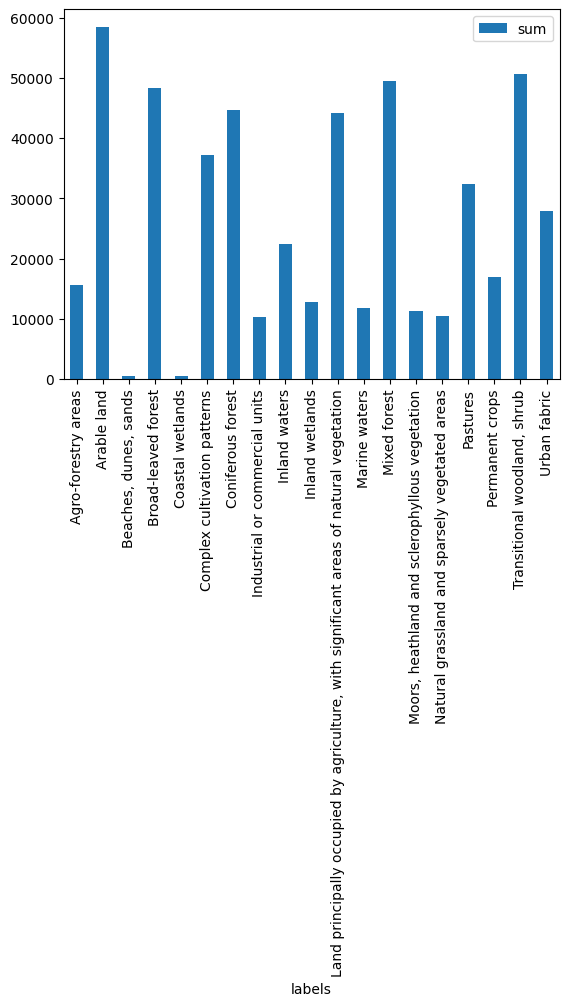

In [22]:
plot_imbalanced(new_sum_df, 'sum')

In [35]:
new_sum_df_train = analyse_inbalance(new_df.loc[new_df['split']=='train'])

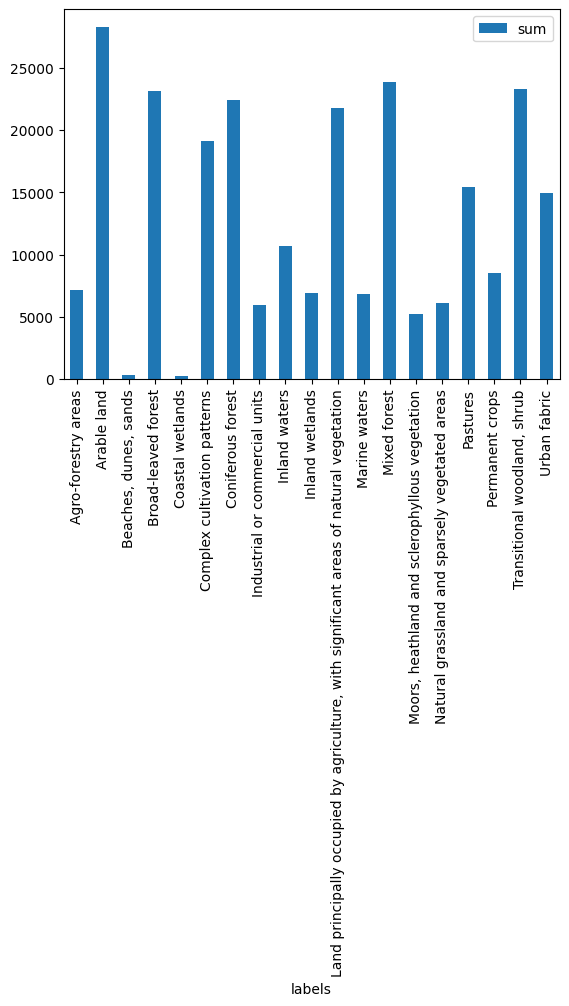

In [36]:
plot_imbalanced(new_sum_df_train, 'sum')

In [37]:
new_sum_df_train

,labels,sum,percent,num_negatives,neg/pos
0,Agro-forestry areas,7156,2.858410,243193,33.984489
1,Arable land,28315,11.310211,222034,7.841568
2,"Beaches, dunes, sands",297,0.118634,250052,841.925926
3,Broad-leaved forest,23144,9.244694,227205,9.817015
4,Coastal wetlands,244,0.097464,250105,1025.020492
5,Complex cultivation patterns,19104,7.630947,231245,12.104533
6,Coniferous forest,22419,8.955099,227930,10.166823
7,Industrial or commercial units,5935,2.370691,244414,41.181803
8,Inland waters,10701,4.274433,239648,22.394916
9,Inland wetlands,6916,2.762543,243433,35.198525


In [30]:
new_df

,patch_id,labels,split,country,s1_name,s2v1_name,contains_seasonal_snow,contains_cloud_or_shadow
110560,S2A_MSIL2A_20171121T112351_N9999_R037_T29SND_7...,"[Agro-forestry areas, Transitional woodland, s...",train,Portugal,S1A_IW_GRDH_1SDV_20171122T063450_29SND_72_79,S2A_MSIL2A_20171121T112351_72_79,False,False
87781,S2A_MSIL2A_20171002T112111_N9999_R037_T29SNC_6...,[Agro-forestry areas],train,Portugal,S1A_IW_GRDH_1SDV_20171005T063451_29SNC_66_1,S2A_MSIL2A_20171002T112111_66_1,False,False
359975,S2B_MSIL2A_20180224T112109_N9999_R037_T29SNC_4...,"[Agro-forestry areas, Pastures, Permanent crop...",test,Portugal,S1B_IW_GRDH_1SDV_20180225T064227_29SNC_42_27,S2B_MSIL2A_20180224T112109_42_27,False,False
361640,S2B_MSIL2A_20180224T112109_N9999_R037_T29SNC_6...,"[Agro-forestry areas, Arable land, Mixed fores...",test,Portugal,S1A_IW_GRDH_1SDV_20180225T183447_29SNC_60_58,S2B_MSIL2A_20180224T112109_60_58,False,False
362059,S2B_MSIL2A_20180224T112109_N9999_R037_T29SNC_6...,"[Agro-forestry areas, Complex cultivation patt...",test,Portugal,S1A_IW_GRDH_1SDV_20180225T183512_29SNC_65_23,S2B_MSIL2A_20180224T112109_65_23,False,False
...,...,...,...,...,...,...,...,...
290820,S2B_MSIL2A_20170927T094019_N9999_R036_T35ULB_1...,"[Arable land, Complex cultivation patterns, La...",validation,Lithuania,S1A_IW_GRDH_1SDV_20170928T161150_35ULB_13_34,S2B_MSIL2A_20170927T094019_13_34,False,False
380228,S2B_MSIL2A_20180421T100029_N9999_R122_T33TWN_1...,"[Arable land, Complex cultivation patterns, Mi...",train,Austria,S1A_IW_GRDH_1SDV_20180421T165021_33TWN_19_90,S2B_MSIL2A_20180421T100030_19_90,False,False
365873,S2B_MSIL2A_20180225T105019_N9999_R051_T31UER_8...,"[Arable land, Complex cultivation patterns, Pa...",train,Belgium,S1A_IW_GRDH_1SDV_20180225T055027_31UER_84_0,S2B_MSIL2A_20180225T105019_84_0,False,False
120866,S2A_MSIL2A_20171208T093351_N9999_R136_T34TEN_1...,"[Broad-leaved forest, Land principally occupie...",validation,Kosovo,S1A_IW_GRDH_1SDV_20171207T162450_34TEN_13_62,S2A_MSIL2A_20171208T093351_13_62,False,False
